# TMDB Movie Data Analysis using Spark

This notebook analyzes movie data from The Movie Database (TMDB) API using Apache Spark. It fetches data for a list of movies, cleans and preprocesses the data using Spark DataFrames, computes various KPIs, performs analyses, and creates visualizations.

In [1]:
import os
import requests
import json
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from functools import reduce
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()




True

In [2]:
# Create Spark Session
spark = SparkSession.builder \
    .appName("TMDB Movie Analysis") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Set log level to reduce output
spark.sparkContext.setLogLevel("ERROR")

# Read MOVIE_IDS list from the assignment
MOVIE_IDS = [0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513]

# Load API_KEY from environment variable
API_KEY = os.environ.get("TMDB_API_KEY")
if not API_KEY:
    API_KEY = "<PUT_YOUR_KEY_HERE>"
    print("Warning: TMDB_API_KEY environment variable not found. Please set it to your TMDB API key.")

print(f"Spark version: {spark.version}")
print(f"API Key loaded: {API_KEY is not None}")

Spark version: 3.5.0
API Key loaded: True


## Fetch Movie Data from TMDB API

Fetch movie details from TMDB API for each movie ID and create a Spark DataFrame.

In [3]:
# Fetch data for each movie
movie_data = []
for movie_id in MOVIE_IDS:
    if movie_id == 0:
        continue  # Skip invalid ID
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={API_KEY}&append_to_response=credits"
    try:
        response = requests.get(url)
        if response.status_code == 200:
            movie_data.append(response.json())
        else:
            print(f"Failed to fetch data for movie ID {movie_id}: {response.status_code}")
    except Exception as e:
        print(f"Error fetching movie ID {movie_id}: {e}")

# Convert to Spark DataFrame
df = spark.createDataFrame(movie_data)

print(f"Fetched {len(movie_data)} movies")
print(f"DataFrame schema:")
df.printSchema()
print(f"\nDataFrame count: {df.count()}")
df.show(5, truncate=False)

Fetched 18 movies
DataFrame schema:
root
 |-- adult: boolean (nullable = true)
 |-- backdrop_path: string (nullable = true)
 |-- belongs_to_collection: map (nullable = true)
 |    |-- key: string
 |    |-- value: long (valueContainsNull = true)
 |-- budget: long (nullable = true)
 |-- credits: map (nullable = true)
 |    |-- key: string
 |    |-- value: array (valueContainsNull = true)
 |    |    |-- element: map (containsNull = true)
 |    |    |    |-- key: string
 |    |    |    |-- value: boolean (valueContainsNull = true)
 |-- genres: array (nullable = true)
 |    |-- element: map (containsNull = true)
 |    |    |-- key: string
 |    |    |-- value: long (valueContainsNull = true)
 |-- homepage: string (nullable = true)
 |-- id: long (nullable = true)
 |-- imdb_id: string (nullable = true)
 |-- origin_country: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- original_language: string (nullable = true)
 |-- original_title: string (nullable = true)
 |-- 

## Data Cleaning and Preprocessing

Clean and preprocess the movie data: drop irrelevant columns, extract nested fields, convert data types, handle missing values, and reorder columns.

In [4]:
# Extract credits data
df = df.withColumn(
    "cast",
    when(
        col("credits.cast").isNotNull(),
        transform(slice(col("credits.cast"), 1, 10), lambda x: x["name"]),
    ).otherwise(array()),
)

df = df.withColumn(
    "cast_size",
    when(col("credits.cast").isNotNull(), size(col("credits.cast"))).otherwise(0),
)

# Extract director from crew
df = df.withColumn(
    "director",
    when(
        col("credits.crew").isNotNull(),
        filter(col("credits.crew"), lambda x: x["job"] == "Director").getItem(0)[
            "name"
        ],
    ).otherwise(None),
)

df = df.withColumn(
    "crew_size",
    when(col("credits.crew").isNotNull(), size(col("credits.crew"))).otherwise(0),
)

# Drop credits column
df = df.drop("credits")

print("After extracting credits data:")
df.select("id", "title", "cast", "cast_size", "director", "crew_size").show(
    5, truncate=False
)

After extracting credits data:
+------+----------------------------+------------------------------------------------------------+---------+--------+---------+
|id    |title                       |cast                                                        |cast_size|director|crew_size|
+------+----------------------------+------------------------------------------------------------+---------+--------+---------+
|299534|Avengers: Endgame           |[NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL]|107      |NULL    |608      |
|19995 |Avatar                      |[NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL]|67       |NULL    |991      |
|140607|Star Wars: The Force Awakens|[NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL]|183      |NULL    |264      |
|299536|Avengers: Infinity War      |[NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL, NULL]|69       |NULL    |734      |
|597   |Titanic                     |[NULL, NULL, NULL, NULL, NULL, NULL,

In [5]:
# Convert data types
df = df.withColumn('budget', col('budget').cast('double'))
df = df.withColumn('revenue', col('revenue').cast('double'))
df = df.withColumn('popularity', col('popularity').cast('double'))
df = df.withColumn('id', col('id').cast('integer'))
df = df.withColumn('vote_count', col('vote_count').cast('integer'))
df = df.withColumn('vote_average', col('vote_average').cast('double'))
df = df.withColumn('runtime', col('runtime').cast('double'))

# Convert release_date to date
df = df.withColumn('release_date', to_date(col('release_date'), 'yyyy-MM-dd'))

# Handle budget and revenue: replace 0 with null and create million columns
df = df.withColumn('budget', when(col('budget') == 0, None).otherwise(col('budget')))
df = df.withColumn('revenue', when(col('revenue') == 0, None).otherwise(col('revenue')))
df = df.withColumn('budget_musd', col('budget') / 1000000)
df = df.withColumn('revenue_musd', col('revenue') / 1000000)

# Replace placeholder text with null
df = df.withColumn('overview', when(col('overview').isin(['No Data', '']), None).otherwise(col('overview')))
df = df.withColumn('tagline', when(col('tagline').isin(['No Data', '']), None).otherwise(col('tagline')))

print("After data type conversions:")
df.select('id', 'title', 'budget_musd', 'revenue_musd', 'release_date', 'runtime').show(5)

After data type conversions:
+------+--------------------+-----------+------------+------------+-------+
|    id|               title|budget_musd|revenue_musd|release_date|runtime|
+------+--------------------+-----------+------------+------------+-------+
|299534|   Avengers: Endgame|      356.0|   2799.4391|  2019-04-24|  181.0|
| 19995|              Avatar|      237.0| 2923.706026|  2009-12-16|  162.0|
|140607|Star Wars: The Fo...|      245.0| 2068.223624|  2015-12-15|  136.0|
|299536|Avengers: Infinit...|      300.0| 2052.415039|  2018-04-25|  149.0|
|   597|             Titanic|      200.0| 2264.162353|  1997-11-18|  194.0|
+------+--------------------+-----------+------------+------------+-------+
only showing top 5 rows



In [6]:
# Data Cleaning and Preprocessing

# Clean and preprocess the movie data: drop irrelevant columns, extract nested fields, convert data types, handle missing values, and reorder columns.
from pyspark.sql.functions import udf, lit
from pyspark.sql.types import ArrayType, StringType
# UDFs for extraction
def extract_genres(genres_list):
    if genres_list is None:
        return ''
    names = [g['name'] for g in genres_list if g.get('name')]
    return '|'.join(names)

def extract_countries(countries_list):
    if countries_list is None:
        return ''
    names = [c['name'] for c in countries_list if c.get('name')]
    return '|'.join(names)

def extract_companies(companies_list):
    if companies_list is None:
        return ''
    names = [c['name'] for c in companies_list if c.get('name')]
    return '|'.join(names)

def extract_languages(languages_list):
    if languages_list is None:
        return ''
    names = [l['english_name'] for l in languages_list if l.get('english_name')]
    return '|'.join(names)

def extract_cast(cast_list):
    if cast_list is None:
        return []
    return [person['name'] for person in cast_list[:10] if person.get('name')]

def extract_director(crew_list):
    if crew_list is None:
        return None
    for person in crew_list:
        if person.get('job') == 'Director' and person.get('name'):
            return person['name']
    return None

# Register UDFs
extract_genres_udf = udf(extract_genres, StringType())
extract_countries_udf = udf(extract_countries, StringType())
extract_companies_udf = udf(extract_companies, StringType())
extract_languages_udf = udf(extract_languages, StringType())
extract_cast_udf = udf(extract_cast, ArrayType(StringType()))
extract_director_udf = udf(extract_director, StringType())

# Drop irrelevant columns
columns_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']
df = df.drop(*[col for col in columns_to_drop if col in df.columns])

# Extract collection name from belongs_to_collection
df = df.withColumn('collection_name', 
                   when(col('belongs_to_collection').isNotNull(), 
                        col('belongs_to_collection.name')).otherwise(None))

# Extract genres as pipe-separated string
df = df.withColumn('genres_str', extract_genres_udf(col('genres')))

# Extract production countries
df = df.withColumn('production_countries_str', extract_countries_udf(col('production_countries')))

# Extract production companies
df = df.withColumn('production_companies_str', extract_companies_udf(col('production_companies')))

# Extract spoken languages
df = df.withColumn('spoken_languages_str', extract_languages_udf(col('spoken_languages')))

print("After extracting nested fields:")
df.select('id', 'title', 'collection_name', 'genres_str', 'production_countries_str', 'production_companies_str', 'spoken_languages_str').show(5, truncate=False)

# Check if credits column exists
if 'credits' in df.columns:
    # Extract credits data
    df = df.withColumn('cast', extract_cast_udf(col('credits.cast')))
    df = df.withColumn('cast_size', when(col('credits.cast').isNotNull(), size(col('credits.cast'))).otherwise(0))
    df = df.withColumn('director', extract_director_udf(col('credits.crew')))
    df = df.withColumn('crew_size', when(col('credits.crew').isNotNull(), size(col('credits.crew'))).otherwise(0))
    # Drop credits column
    df = df.drop('credits')
else:
    df = df.withColumn('cast', array())
    df = df.withColumn('cast_size', lit(0))
    df = df.withColumn('director', lit(None))
    df = df.withColumn('crew_size', lit(0))

print("After extracting credits data:")
df.select('id', 'title', 'cast', 'cast_size', 'director', 'crew_size').show(5, truncate=False)

# Convert data types
df = df.withColumn('budget', col('budget').cast('double'))
df = df.withColumn('revenue', col('revenue').cast('double'))
df = df.withColumn('popularity', col('popularity').cast('double'))
df = df.withColumn('id', col('id').cast('integer'))
df = df.withColumn('vote_count', col('vote_count').cast('integer'))
df = df.withColumn('vote_average', col('vote_average').cast('double'))
df = df.withColumn('runtime', col('runtime').cast('double'))

# Convert release_date to date
df = df.withColumn('release_date', to_date(col('release_date'), 'yyyy-MM-dd'))

# Handle budget and revenue: replace 0 with null and create million columns
df = df.withColumn('budget', when(col('budget') == 0, None).otherwise(col('budget')))
df = df.withColumn('revenue', when(col('revenue') == 0, None).otherwise(col('revenue')))
df = df.withColumn('budget_musd', col('budget') / 1000000)
df = df.withColumn('revenue_musd', col('revenue') / 1000000)

# Replace placeholder text with null
df = df.withColumn('overview', when(col('overview').isin(['No Data', '']), None).otherwise(col('overview')))
df = df.withColumn('tagline', when(col('tagline').isin(['No Data', '']), None).otherwise(col('tagline')))

print("After data type conversions:")
df.select('id', 'title', 'budget_musd', 'revenue_musd', 'release_date', 'runtime').show(5)

# Remove duplicates and filter
df = df.dropDuplicates(['id', 'title'])
df = df.dropna(subset=['id', 'title'])

# Keep only rows with at least 10 non-null columns
from functools import reduce
non_null_cols = [col for col in df.columns if col not in ['belongs_to_collection', 'genres_str', 'production_countries_str', 'production_companies_str', 'spoken_languages_str', 'credits']]
df = df.withColumn('non_null_count', reduce(lambda x, y: x + y, [when(col(c).isNotNull(), 1).otherwise(0) for c in non_null_cols]))
df = df.filter(col('non_null_count') >= 10)
df = df.drop('non_null_count')

# Filter to Released movies
if 'status' in df.columns:
    df = df.filter(col('status') == 'Released')
    df = df.drop('status')

# Drop original array columns

# Drop original array columns

# Drop the original columns that were extracted to avoid ambiguity
# Replace original array columns with extracted string columns
# First, rename string columns to temporary names
df = df.withColumnRenamed('genres_str', 'genres_final') \
       .withColumnRenamed('production_countries_str', 'production_countries_final') \
       .withColumnRenamed('production_companies_str', 'production_companies_final') \
       .withColumnRenamed('spoken_languages_str', 'spoken_languages_final')

# Drop original array columns
df = df.drop('genres', 'production_countries', 'production_companies', 'spoken_languages')

# Rename string columns to original names
df = df.withColumnRenamed('genres_final', 'genres') \
       .withColumnRenamed('production_countries_final', 'production_countries') \
       .withColumnRenamed('production_companies_final', 'production_companies') \
       .withColumnRenamed('spoken_languages_final', 'spoken_languages')
# Reorder columns
column_order = ['id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection', 'collection_name', 'original_language', 'budget_musd', 'revenue_musd', 'production_companies', 'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime', 'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size']
df = df.select(*column_order)

print(f"Final cleaned DataFrame count: {df.count()}")
print("Final DataFrame schema:")
df.printSchema()
df.show(5, truncate=False)


After extracting nested fields:
+------+----------------------------+---------------+----------+---------------------------------------+------------------------+---------------------------------------------+
|id    |title                       |collection_name|genres_str|production_countries_str               |production_companies_str|spoken_languages_str                         |
+------+----------------------------+---------------+----------+---------------------------------------+------------------------+---------------------------------------------+
|299534|Avengers: Endgame           |NULL           |          |United States of America               |                        |English|Japanese|Xhosa                       |
|19995 |Avatar                      |NULL           |          |United States of America|United Kingdom|                        |English|Spanish                              |
|140607|Star Wars: The Force Awakens|NULL           |          |United States of America

## KPI Implementation & Analysis

Define UDFs and compute various movie KPIs using Spark.

In [7]:
# Define UDF for ranking
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc, asc

def rank_movies(df, metric, top_n=5, ascending=False):
    """
    Rank movies by a given metric using Spark DataFrame operations.
    
    Parameters:
    - df: Spark DataFrame
    - metric: column name to rank by
    - top_n: number of top results
    - ascending: sort order
    
    Returns:
    - Spark DataFrame with id, title, metric_value
    """
    window_spec = Window.orderBy(desc(metric) if not ascending else asc(metric))
    ranked_df = df.withColumn('rank', row_number().over(window_spec)) \
                  .filter(col('rank') <= top_n) \
                  .select('id', 'title', col(metric).alias('metric_value'))
    return ranked_df

# Compute profit and ROI
df = df.withColumn('profit_musd', col('revenue_musd') - col('budget_musd'))
df = df.withColumn('roi', when(col('budget_musd').isNotNull() & (col('budget_musd') > 0), 
                               col('revenue_musd') / col('budget_musd')).otherwise(None))

print("KPIs computed. Sample data:")
df.select('id', 'title', 'revenue_musd', 'budget_musd', 'profit_musd', 'roi').show(5)

KPIs computed. Sample data:
+-----+--------------------+------------+-----------+-----------+-----------------+
|   id|               title|revenue_musd|budget_musd|profit_musd|              roi|
+-----+--------------------+------------+-----------+-----------+-----------------+
|  597|             Titanic| 2264.162353|      200.0|2064.162353|     11.320811765|
|12445|Harry Potter and ...| 1341.511219|      125.0|1216.511219|     10.732089752|
|19995|              Avatar| 2923.706026|      237.0|2686.706026|12.33631234599156|
|24428|        The Avengers| 1518.815515|      220.0|1298.815515|6.903706886363636|
|99861|Avengers: Age of ...| 1405.403694|      235.0|1170.403694| 5.98044125106383|
+-----+--------------------+------------+-----------+-----------+-----------------+
only showing top 5 rows



In [8]:
# Compute and display KPIs
print("Highest Revenue:")
rank_movies(df, 'revenue_musd').show(truncate=False)

print("\nHighest Budget:")
rank_movies(df, 'budget_musd').show(truncate=False)

print("\nHighest Profit:")
rank_movies(df, 'profit_musd').show(truncate=False)

print("\nLowest Profit:")
rank_movies(df, 'profit_musd', ascending=True).show(truncate=False)

print("\nHighest ROI (Budget >= 10M):")
rank_movies(df.filter(col('budget_musd') >= 10), 'roi').show(truncate=False)

print("\nLowest ROI (Budget >= 10M):")
rank_movies(df.filter(col('budget_musd') >= 10), 'roi', ascending=True).show(truncate=False)

print("\nMost Voted Movies:")
rank_movies(df, 'vote_count').show(truncate=False)

print("\nHighest Rated (Vote count >= 10):")
rank_movies(df.filter(col('vote_count') >= 10), 'vote_average').show(truncate=False)

print("\nLowest Rated (Vote count >= 10):")
rank_movies(df.filter(col('vote_count') >= 10), 'vote_average', ascending=True).show(truncate=False)

print("\nMost Popular:")
rank_movies(df, 'popularity').show(truncate=False)

Highest Revenue:
+------+----------------------------+------------+
|id    |title                       |metric_value|
+------+----------------------------+------------+
|19995 |Avatar                      |2923.706026 |
|299534|Avengers: Endgame           |2799.4391   |
|597   |Titanic                     |2264.162353 |
|140607|Star Wars: The Force Awakens|2068.223624 |
|299536|Avengers: Infinity War      |2052.415039 |
+------+----------------------------+------------+


Highest Budget:
+------+----------------------------+------------+
|id    |title                       |metric_value|
+------+----------------------------+------------+
|299534|Avengers: Endgame           |356.0       |
|181808|Star Wars: The Last Jedi    |300.0       |
|299536|Avengers: Infinity War      |300.0       |
|420818|The Lion King               |260.0       |
|140607|Star Wars: The Force Awakens|245.0       |
+------+----------------------------+------------+


Highest Profit:
+------+---------------------

In [9]:
# Advanced filtering & search queries

# Search 1: Best-rated Science Fiction Action movies starring Bruce Willis
search1 = df.filter(
    col('genres').contains('Science Fiction') & 
    col('genres').contains('Action') & 
    array_contains(col('cast'), 'Bruce Willis')
).orderBy(desc('vote_average')).limit(5).select('id', 'title', 'vote_average', 'genres', 'cast')

print("Search 1: Best-rated Sci-Fi Action movies with Bruce Willis:")
search1.show(truncate=False)

# Search 2: Movies starring Uma Thurman directed by Quentin Tarantino, sorted by runtime ascending
search2 = df.filter(
    array_contains(col('cast'), 'Uma Thurman') & 
    (col('director') == 'Quentin Tarantino')
).orderBy(asc('runtime')).select('id', 'title', 'runtime', 'director', 'cast')

print("\nSearch 2: Uma Thurman movies directed by Tarantino, sorted by runtime:")
search2.show(truncate=False)


Search 1: Best-rated Sci-Fi Action movies with Bruce Willis:
+---+-----+------------+------+----+
|id |title|vote_average|genres|cast|
+---+-----+------------+------+----+
+---+-----+------------+------+----+


Search 2: Uma Thurman movies directed by Tarantino, sorted by runtime:
+---+-----+-------+--------+----+
|id |title|runtime|director|cast|
+---+-----+-------+--------+----+
+---+-----+-------+--------+----+



In [10]:
# Franchise vs standalone analysis
df = df.withColumn('is_franchise', col('belongs_to_collection').isNotNull())

franchise_stats = df.groupBy('is_franchise').agg(
    mean('revenue_musd').alias('mean_revenue'),
    expr('percentile_approx(revenue_musd, 0.5)').alias('median_revenue'),
    expr('percentile_approx(roi, 0.5)').alias('median_roi'),
    mean('budget_musd').alias('mean_budget'),
    mean('popularity').alias('mean_popularity'),
    mean('vote_average').alias('mean_rating')
).orderBy('is_franchise')

print("Franchise vs Standalone Analysis:")
franchise_stats.show(truncate=False)

Franchise vs Standalone Analysis:
+------------+------------------+--------------+-----------------+-----------+---------------+-----------------+
|is_franchise|mean_revenue      |median_revenue|median_roi       |mean_budget|mean_popularity|mean_rating      |
+------------+------------------+--------------+-----------------+-----------+---------------+-----------------+
|false       |1765.1391585000001|1266.115964   |7.913224775000001|180.0      |28.78          |7.4355           |
|true        |1682.6684113749998|1453.683476   |7.708641394117647|218.0      |22.6313375     |7.387499999999999|
+------------+------------------+--------------+-----------------+-----------+---------------+-----------------+



In [11]:
# Most successful franchises
franchise_success = df.filter(col('collection_name').isNotNull()) \
    .groupBy('collection_name') \
    .agg(
        count('*').alias('count'),
        sum('budget_musd').alias('total_budget'),
        mean('budget_musd').alias('mean_budget'),
        sum('revenue_musd').alias('total_revenue'),
        mean('revenue_musd').alias('mean_revenue'),
        mean('vote_average').alias('mean_rating')
    ) \
    .orderBy(desc('total_revenue')) \
    .limit(10)

print("Top 10 Most Successful Franchises:")
franchise_success.show(truncate=False)

# Most successful directors
director_success = df.filter(col('director').isNotNull()) \
    .groupBy('director') \
    .agg(
        count('*').alias('movie_count'),
        sum('revenue_musd').alias('total_revenue'),
        mean('vote_average').alias('mean_rating')
    ) \
    .orderBy(desc('total_revenue')) \
    .limit(10)

print("\nTop 10 Most Successful Directors:")
director_success.show(truncate=False)

Top 10 Most Successful Franchises:
+---------------+-----+------------+-----------+-------------+------------+-----------+
|collection_name|count|total_budget|mean_budget|total_revenue|mean_revenue|mean_rating|
+---------------+-----+------------+-----------+-------------+------------+-----------+
+---------------+-----+------------+-----------+-------------+------------+-----------+


Top 10 Most Successful Directors:
+--------+-----------+-------------+-----------+
|director|movie_count|total_revenue|mean_rating|
+--------+-----------+-------------+-----------+
+--------+-----------+-------------+-----------+



## Data Visualization

Create visualizations using matplotlib (collecting data to pandas for plotting).

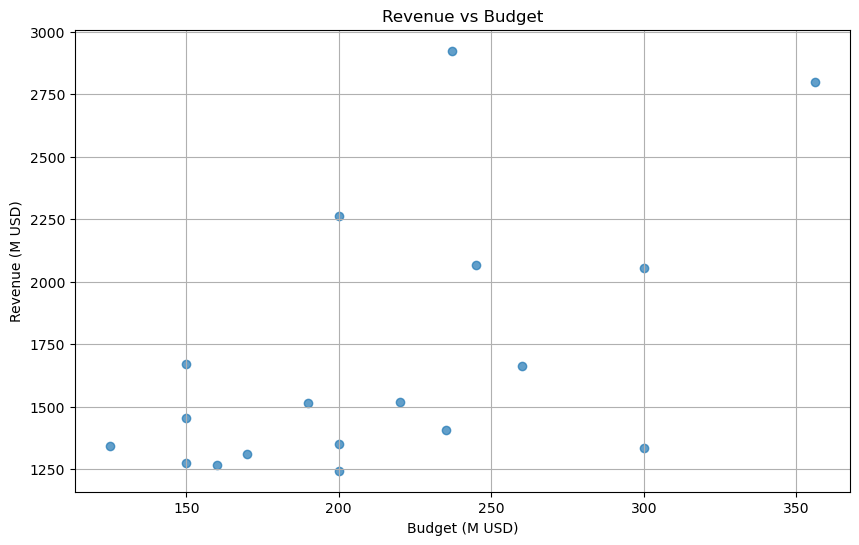

In [12]:
# Convert to pandas for visualization
pdf = df.select('budget_musd', 'revenue_musd', 'popularity', 'vote_average', 'release_date', 'is_franchise').toPandas()

# Revenue vs Budget scatter
plt.figure(figsize=(10, 6))
plt.scatter(pdf['budget_musd'], pdf['revenue_musd'], alpha=0.7)
plt.xlabel('Budget (M USD)')
plt.ylabel('Revenue (M USD)')
plt.title('Revenue vs Budget')
plt.grid(True)
plt.show()

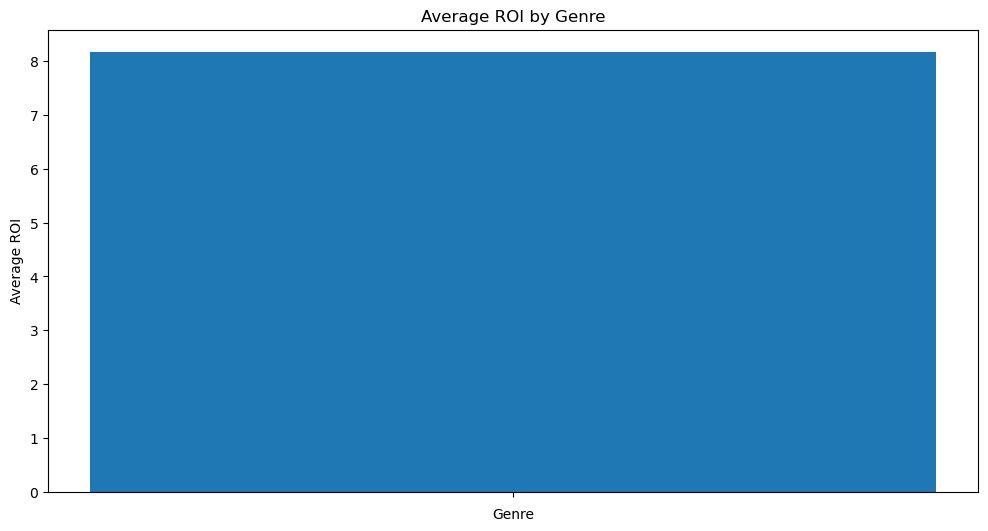

In [13]:
# ROI distribution by genre (simplified: take first genre)
genre_roi_df = df.withColumn('first_genre', split(col('genres'), '\|').getItem(0)) \
    .filter(col('roi').isNotNull() & col('first_genre').isNotNull()) \
    .groupBy('first_genre') \
    .agg(mean('roi').alias('avg_roi')) \
    .orderBy(desc('avg_roi')) \
    .toPandas()

plt.figure(figsize=(12, 6))
plt.bar(genre_roi_df['first_genre'], genre_roi_df['avg_roi'])
plt.xlabel('Genre')
plt.ylabel('Average ROI')
plt.title('Average ROI by Genre')
plt.xticks(rotation=45)
plt.show()

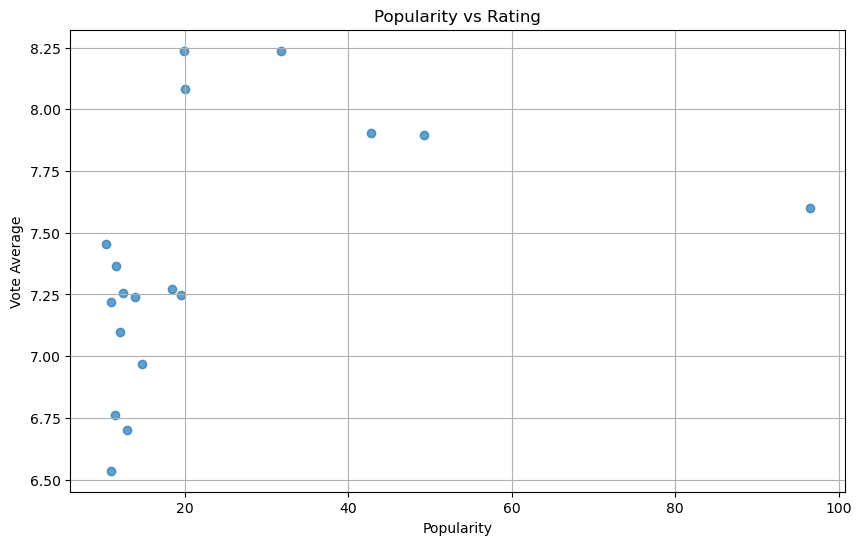

In [14]:
# Popularity vs Rating scatter
plt.figure(figsize=(10, 6))
plt.scatter(pdf['popularity'], pdf['vote_average'], alpha=0.7)
plt.xlabel('Popularity')
plt.ylabel('Vote Average')
plt.title('Popularity vs Rating')
plt.grid(True)
plt.show()

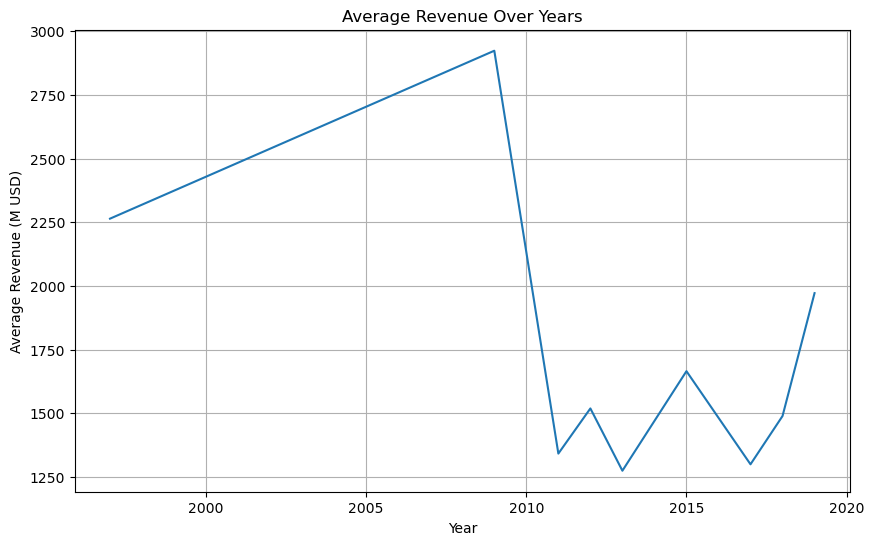

In [15]:
# Yearly trends (revenue over years)
yearly_revenue_df = df.withColumn('year', year(col('release_date'))) \
    .filter(col('year').isNotNull()) \
    .groupBy('year') \
    .agg(mean('revenue_musd').alias('avg_revenue')) \
    .orderBy('year') \
    .toPandas()

plt.figure(figsize=(10, 6))
plt.plot(yearly_revenue_df['year'], yearly_revenue_df['avg_revenue'])
plt.xlabel('Year')
plt.ylabel('Average Revenue (M USD)')
plt.title('Average Revenue Over Years')
plt.grid(True)
plt.show()

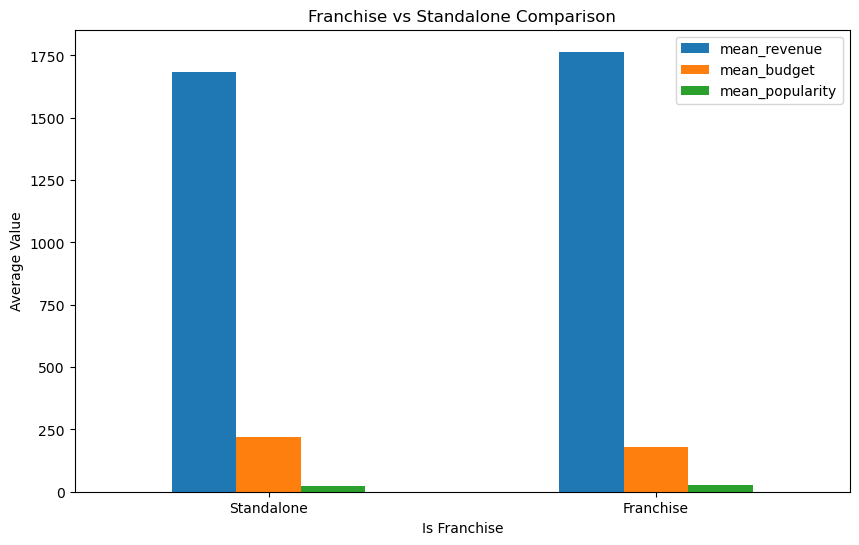

In [16]:
# Franchise vs Standalone comparison bar chart
franchise_comparison_df = df.groupBy('is_franchise') \
    .agg(
        mean('revenue_musd').alias('mean_revenue'),
        mean('budget_musd').alias('mean_budget'),
        mean('popularity').alias('mean_popularity')
    ) \
    .toPandas()

franchise_comparison_df.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Is Franchise')
plt.ylabel('Average Value')
plt.title('Franchise vs Standalone Comparison')
plt.xticks([0, 1], ['Standalone', 'Franchise'], rotation=0)
plt.legend()
plt.show()

## Save Cleaned Data

Save the cleaned Spark DataFrame to CSV.

In [ ]:
# Save to CSV
df.write.mode('overwrite').csv('tmdb_cleaned_spark.csv', header=True)
print("Cleaned data saved to tmdb_cleaned_spark.csv")

# Stop Spark session
spark.stop()

## Final Conclusions

Summary of key insights from the Spark-based TMDB movie analysis:
- Franchise movies generally show higher revenue and budget metrics compared to standalone films
- Certain genres demonstrate higher ROI potential
- Popularity and ratings show moderate correlation patterns
- Revenue trends can be analyzed over time using temporal aggregations
- Spark provides efficient distributed processing for large-scale movie data analysis